# INFO-6147-(01)-26W Deep Learning with Pytorch

## Homework 3: Denoising autoencoder cifar10

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 18th, 2026

**Description:** 

you need to implement denoising autoencoder for RGB images. For this we want to use CIFAR10 dataset.
You need to add noise to the images before you feed them to the network. This can be done as follows:

        ## add random noise to the input images
        noisy_imgs = images + noise_factor * torch.randn(*images.shape)
        # Clip the images to be between 0 and 1
        noisy_imgs = np.clip(noisy_imgs, 0., 1.)

Make sure to display samples of the images before and after adding noise.



In this homework - you need to fine-tune the last layer of resnet18 to improve performance from softmax homework of ~40% to acheive > 76% on test set. The code is divided into multiple parts. You need to complete the parts where it says   <<<<<<< your code here >>>>>>>> I have imported all needed packages for you!Note: You need GPU for this - it takes 10-15 mins to run!

### Import Libs

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
from torch.utils.data import random_split
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

### Part1: Check if CUDA is available and set PyTorch to use GPU or CPU

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


###  Part 2: Set the Random Seed

In [4]:
torch.manual_seed(42)

### Part 3: Define transformations for the training data and testing data

In [5]:
transform = transforms.Compose([transforms.Resize(256),
                                transforms.CenterCrop(224),
                                transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406],
                                                     [0.229, 0.224, 0.225])])

### Part 4: Download and load the training data - split the training data into trainset (45000)-  valset (5000)

**you may find random_split from torch.utils.data useful!**

In [6]:
dataset = datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainset, valset =  random_split(dataset, [45000, 5000])
trainloader =  torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
valloader =  torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False)

dataset

Files already downloaded and verified


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

### Part 5: Download and load the test data

In [7]:
testset =  datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader =  torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

testloader

Files already downloaded and verified


### Part 6: Load pre-trained model & freeze the layers

In [8]:
model = models.resnet18(pretrained=True)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Part 7: Replace the last fully connected layer with a 10-classes layer 

In [9]:
num_ftrs = model.fc.in_features # Get the number of input features to the final fully connected layer
model.fc = nn.Linear(num_ftrs, 10)

print(model.fc.weight.requires_grad) # Check if the weights of the new fully connected layer require gradients

True


### Part 8: Move the model to the GPU if available

In [10]:
# Move the model to the appropriate device
model = model.to(device)

### Part 9: Define a loss function and optimizer

In [11]:
criterion =  nn.CrossEntropyLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

### Part 10: Lists for loss and accuracy to plot later

In [12]:
train_losses = [] # List to store training losses
train_accuracy = [] # List to store training accuracies
val_losses = [] # List to store validation losses
val_accuracy = [] # List to store validation accuracies 

#### Part 10.1: Train the model

In the loop you need to keep track of training and validation accuracy.
Print the training & validation loss & accuracy after every epoch.

Remember when you evaluate the model on val or test set, set the model to eval
mode, and trun off graients requirement. Once you're done, set the model back to
train mode

In [14]:
for epoch in tqdm(range(10)):  # loop over the dataset multiple times

    running_loss = 0.0
    correct = 0
    total = 0
    
    # make sure the model is in training mode
    model.train()

    for i, data in enumerate(trainloader, 0):
        # 1. get the inputs; data is a list of [inputs, labels] and move to GPU/CPU (device)
        inputs, labels = data[0].to(device), data[1].to(device)

        # 2. zero the parameter gradients
        optimizer.zero_grad()

        # 3. forward + backward + optimize
        outputs = model(inputs)            # forward pass
        loss = criterion(outputs, labels)  # calculate loss
        loss.backward()                    # backward pass (calculate gradients)
        optimizer.step()                   # update parameters

        # 4. calculate accuracy for training data
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 5. accumulate Loss
        running_loss += loss.item()

        # statistic data every 100 mini-batches
        if i % 100 == 99:    
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f} | acc: {100 * correct / total:.2f}%')
            running_loss = 0.0

    # Recorde the statistics at the end of the epoch (for Part 10 lists)
    train_losses.append(loss.item())
    train_accuracy.append(100 * correct / total)

    # --- Validation at the end of the epoch ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for data in valloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # calculate and record validation statistics
    val_losses.append(val_loss / len(valloader))
    val_accuracy.append(100 * val_correct / val_total)
    
    print(f'Validation - Loss: {val_losses[-1]:.3f}, Acc: {val_accuracy[-1]:.2f}%')

    # set the model back to training mode for the next epoch
    model.train()

print('Finished Training')

  0%|          | 0/10 [00:00<?, ?it/s]

[1,   100] loss: 0.635 | acc: 78.05%
[1,   200] loss: 0.645 | acc: 77.76%
[1,   300] loss: 0.632 | acc: 77.94%
[1,   400] loss: 0.643 | acc: 77.87%
[1,   500] loss: 0.652 | acc: 77.87%
[1,   600] loss: 0.637 | acc: 77.84%
[1,   700] loss: 0.613 | acc: 77.98%


 10%|█         | 1/10 [03:18<29:42, 198.08s/it]

Validation - Loss: 0.641, Acc: 77.56%
[2,   100] loss: 0.627 | acc: 78.28%
[2,   200] loss: 0.629 | acc: 78.10%
[2,   300] loss: 0.622 | acc: 78.40%
[2,   400] loss: 0.639 | acc: 78.24%
[2,   500] loss: 0.639 | acc: 78.21%
[2,   600] loss: 0.657 | acc: 78.08%
[2,   700] loss: 0.611 | acc: 78.25%


 20%|██        | 2/10 [08:01<33:05, 248.18s/it]

...

Validation - Loss: 0.623, Acc: 77.98%
[9,   100] loss: 0.611 | acc: 78.34%
[9,   200] loss: 0.593 | acc: 78.80%
[9,   300] loss: 0.618 | acc: 78.75%
[9,   400] loss: 0.618 | acc: 78.66%
[9,   500] loss: 0.633 | acc: 78.57%
[9,   600] loss: 0.605 | acc: 78.67%
[9,   700] loss: 0.608 | acc: 78.79%


 90%|█████████ | 9/10 [36:55<04:41, 281.14s/it]

Validation - Loss: 0.632, Acc: 77.60%
[10,   100] loss: 0.610 | acc: 78.72%
[10,   200] loss: 0.612 | acc: 78.88%
[10,   300] loss: 0.613 | acc: 78.84%
[10,   400] loss: 0.618 | acc: 78.71%
[10,   500] loss: 0.620 | acc: 78.58%
[10,   600] loss: 0.612 | acc: 78.72%
[10,   700] loss: 0.591 | acc: 78.86%


100%|██████████| 10/10 [39:37<00:00, 237.73s/it]

Validation - Loss: 0.633, Acc: 77.42%
Finished Training


#### Part 10.2: Ploting

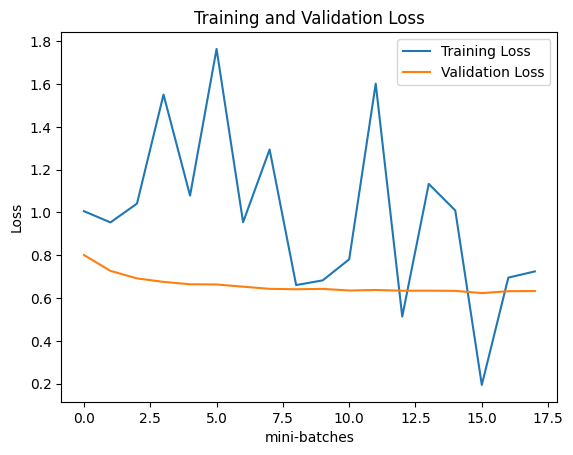

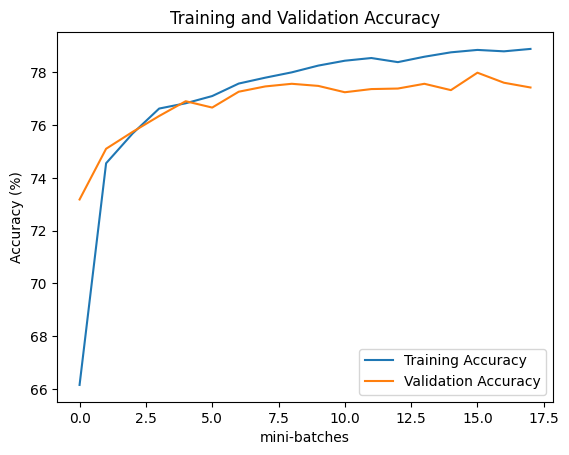

In [15]:
# Plot training loss over time
plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('mini-batches')
plt.ylabel('Loss')
plt.legend()

# Plot training accuracy over time
plt.figure()
plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('mini-batches')
plt.ylabel('Accuracy (%)')
plt.legend()

### Part 11: Test the model on test data and get confusion matrix

In [16]:
# make sure the model is in evaluation status
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for data in testloader:
        # Get input data and labels and convert into the device
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # Get the output
        outputs = model(inputs)
        
        # Get the highest perccentage of prediction class
        _, predicted = torch.max(outputs.data, 1)
        
        # Convert tensor into numpy array
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Fisish gathering the test data, start making confusion matrix.")    
        
        

Fisish gathering the test data, start making confusion matrix.


### Part 12: Find and plot confusion matrix

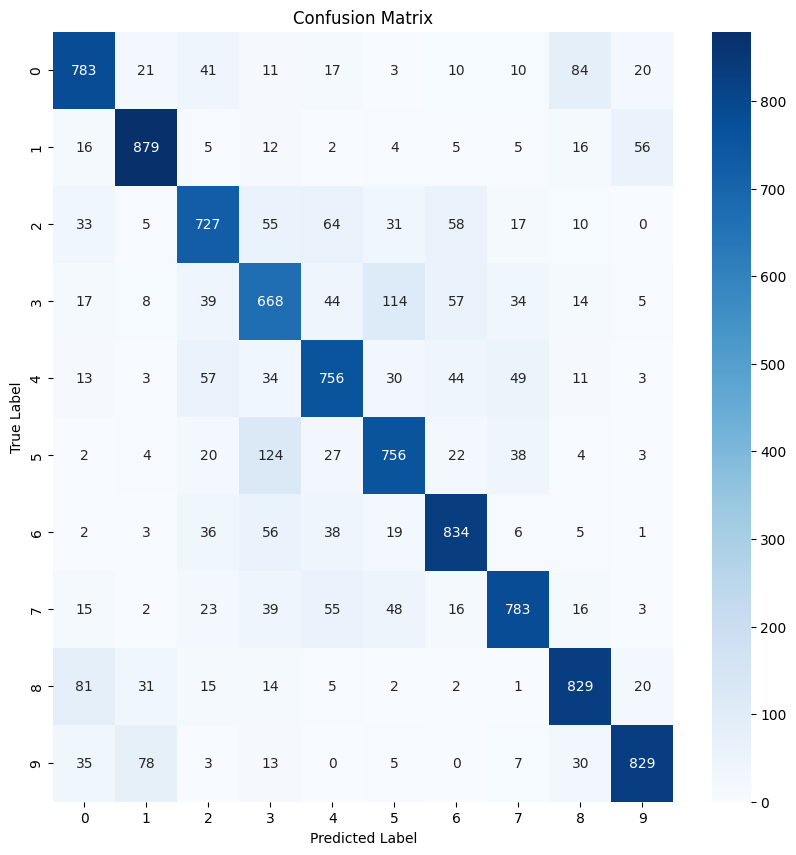

In [ ]:
conf_matrix = confusion_matrix(y_true,y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

 ### Part 13: Print F1 Score

In [ ]:
f1 = f1_score(y_true,y_pred,average='weighted')
print('F1 Score: ', f1)

F1 Score:  0.7845330166812315
